In [55]:
!pip install pennylane matplotlib scipy numpy

In [56]:
import pennylane as qml
from pennylane import numpy as np

import matplotlib.pyplot as plt

from scipy.linalg import svdvals

In [57]:
# ==========================================
# Experiment Configuration
# ==========================================

# Number of qubits
N_QUBITS = 10

# Maximum circuit depth
MAX_DEPTH = 20

# Number of random circuits per depth
N_SAMPLES = 50

# Quantum simulator
dev = qml.device("default.qubit", wires=N_QUBITS)

In [58]:
# ==========================================
# Hardware Efficient Ansatz (HEA)
# ==========================================
#
# Each layer:
# 1. RY rotations on every qubit
# 2. Chain of CNOTs
#
# This architecture is known to develop
# barren plateaus as depth increases.
#
# ==========================================

def HEA(params, depth):

    param_idx = 0

    for d in range(depth):

        # Single-qubit rotations
        for qubit in range(N_QUBITS):

            qml.RY(
                params[param_idx],
                wires=qubit
            )

            param_idx += 1

        # Entangling layer
        for qubit in range(N_QUBITS - 1):

            qml.CNOT(
                wires=[qubit, qubit + 1]
            )

In [59]:
# ==========================================
# Returns full quantum state
#
# Needed for entropy calculation
# ==========================================

@qml.qnode(dev)

def state_circuit(params, depth):

    HEA(params, depth)

    return qml.state()

In [60]:
# ==========================================
# Simple cost function
#
# Expectation value of Z on qubit 0
#
# We will compute gradients of this
# expectation value.
# ==========================================

@qml.qnode(dev)

def cost_circuit(params, depth):

    HEA(params, depth)

    return qml.expval(
        qml.PauliZ(0)
    )

In [61]:
# ==========================================
# Compute bipartite entanglement entropy
#
# Partition:
#
# Left half  | Right half
#
# Qubits:
# 0 1 2      | 3 4 5
#
# Uses Schmidt coefficients directly.
#
# ==========================================

def bipartite_entropy(state):

    # Reshape state into matrix

    state_matrix = state.reshape(
        (2**(N_QUBITS//2),
         2**(N_QUBITS - N_QUBITS//2))
    )

    # Schmidt coefficients
    singular_values = svdvals(
        state_matrix
    )

    # Probabilities
    probs = singular_values**2

    probs = probs[
        probs > 1e-12
    ]

    # Von Neumann entropy

    entropy = -np.sum(
        probs * np.log2(probs)
    )

    return entropy

In [62]:
# ==========================================
# Main Experiment
#
# For each depth:
#
# 1. Generate random circuits
# 2. Measure entropy
# 3. Measure gradient variance
#
# ==========================================

avg_entropies = []

avg_gradient_variances = []

for depth in range(1, MAX_DEPTH + 1):

    depth_entropies = []

    depth_gradients = []

    print(f"Depth {depth}")

    for sample in range(N_SAMPLES):

        # Random parameters

        params = np.random.uniform(
            low=0,
            high=2*np.pi,
            size=depth * N_QUBITS,
            requires_grad=True
        )

        # -------------------------
        # Entropy
        # -------------------------

        state = state_circuit(
            params,
            depth
        )

        entropy = bipartite_entropy(
            state
        )

        depth_entropies.append(
            entropy
        )

        # -------------------------
        # Gradient
        # -------------------------

        grad_fn = qml.grad(
            cost_circuit
        )

        gradients = grad_fn(
            params,
            depth
        )

        depth_gradients.extend(
            np.abs(gradients)
        )

    avg_entropies.append(
        np.mean(depth_entropies)
    )

    avg_gradient_variances.append(
        np.var(depth_gradients)
    )

Depth 1
Depth 2
Depth 3
Depth 4
Depth 5
Depth 6
Depth 7
Depth 8
Depth 9
Depth 10
Depth 11
Depth 12
Depth 13
Depth 14
Depth 15


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, MAX_DEPTH+1),
    avg_entropies,
    marker='o'
)

plt.xlabel("Circuit Depth")

plt.ylabel("Average Entanglement Entropy")

plt.title(
    "Entropy Growth vs Circuit Depth"
)

plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, MAX_DEPTH+1),
    avg_gradient_variances,
    marker='o'
)

plt.yscale("log")

plt.xlabel("Circuit Depth")

plt.ylabel(
    "Gradient Variance (log scale)"
)

plt.title(
    "Gradient Variance vs Circuit Depth"
)

plt.grid(True)

plt.show()

In [ ]:
fig, ax1 = plt.subplots(
    figsize=(10,6)
)

ax1.plot(
    range(1, MAX_DEPTH+1),
    avg_entropies,
    marker='o',
    label='Entropy'
)

ax1.set_xlabel(
    "Circuit Depth"
)

ax1.set_ylabel(
    "Entropy"
)

ax2 = ax1.twinx()

ax2.plot(
    range(1, MAX_DEPTH+1),
    avg_gradient_variances,
    marker='s'
)

ax2.set_yscale("log")

ax2.set_ylabel(
    "Gradient Variance (log)"
)

plt.title(
    "Entropy Growth vs Gradient Collapse"
)

plt.show()

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(avg_entropies, np.log2(avg_gradient_variances))
plt.xlabel("Entanglement Entropy S")
plt.ylabel("log2(Gradient Variance)")
plt.title("Testing σ² ∝ 2^(-S)")
plt.grid(True)
plt.show()

In [63]:
# ==========================================
# Sparse Entanglement Ansatz
#
# Same rotations as HEA
# BUT much fewer CNOT gates
#
# Goal:
# Slow information propagation
#
# ==========================================

def Sparse_HEA(params, depth):

    param_idx = 0

    for d in range(depth):

        # Rotation layer

        for qubit in range(N_QUBITS):

            qml.RY(
                params[param_idx],
                wires=qubit
            )

            param_idx += 1

        # Sparse entanglement

        qml.CNOT(wires=[0,1])
        qml.CNOT(wires=[2,3])
        qml.CNOT(wires=[4,5])

In [64]:
# ==========================================
# State circuit for sparse ansatz
# ==========================================

@qml.qnode(dev)
def sparse_state_circuit(params, depth):

    Sparse_HEA(params, depth)

    return qml.state()

In [65]:
# ==========================================
# Cost circuit for sparse ansatz
# ==========================================

@qml.qnode(dev)
def sparse_cost_circuit(params, depth):

    Sparse_HEA(params, depth)

    return qml.expval(qml.PauliZ(0))

In [ ]:
# ==========================================
# Run same experiment
# ==========================================

sparse_entropies = []

sparse_gradient_variances = []

for depth in range(1, MAX_DEPTH + 1):

    depth_entropies = []

    depth_gradients = []

    print(f"Sparse Depth {depth}")

    for sample in range(N_SAMPLES):

        params = np.random.uniform(
            0,
            2*np.pi,
            size=depth * N_QUBITS,
            requires_grad=True
        )

        state = sparse_state_circuit(
            params,
            depth
        )

        entropy = bipartite_entropy(state)

        depth_entropies.append(entropy)

        grad_fn = qml.grad(
            sparse_cost_circuit
        )

        gradients = grad_fn(
            params,
            depth
        )

        depth_gradients.extend(
            np.abs(gradients)
        )

    sparse_entropies.append(
        np.mean(depth_entropies)
    )

    sparse_gradient_variances.append(
        np.var(depth_gradients)
    )

In [ ]:
# ==========================================
# Compare Entropy
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
    range(1, MAX_DEPTH+1),
    avg_entropies,
    label="HEA"
)

plt.plot(
    range(1, MAX_DEPTH+1),
    sparse_entropies,
    label="Sparse HEA"
)

plt.xlabel("Depth")
plt.ylabel("Entropy")
plt.title("Entropy Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# Compare Gradient Variance
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
    range(1, MAX_DEPTH+1),
    avg_gradient_variances,
    label="HEA"
)

plt.plot(
    range(1, MAX_DEPTH+1),
    sparse_gradient_variances,
    label="Sparse HEA"
)

plt.yscale("log")

plt.xlabel("Depth")
plt.ylabel("Gradient Variance")
plt.title("Gradient Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [66]:
# ==========================================
# Brick-Wall Ansatz
#
# Same rotations as HEA
# BUT entangling gates alternate between
# two disjoint patterns each layer:
#
# Even layers: (0,1) (2,3) (4,5)
# Odd  layers: (1,2) (3,4)
#
# This is a fully connected circuit
# (information eventually reaches every
# qubit), but spreads at a linear
# "light cone" rate of ~1 qubit per layer,
# instead of the full chain's near-instant
# spread within a single layer.
#
# ==========================================

def BrickWall_HEA(params, depth):

    param_idx = 0

    for d in range(depth):

        # Rotation layer
        for qubit in range(N_QUBITS):

            qml.RY(
                params[param_idx],
                wires=qubit
            )

            param_idx += 1

        # Alternating entangling pattern
        if d % 2 == 0:

            # Even layer: pairs (0,1), (2,3), (4,5)
            for q in range(0, N_QUBITS - 1, 2):
                qml.CNOT(wires=[q, q + 1])

        else:

            # Odd layer: pairs (1,2), (3,4)
            for q in range(1, N_QUBITS - 1, 2):
                qml.CNOT(wires=[q, q + 1])

In [67]:
# ==========================================
# State circuit for brick-wall ansatz
# ==========================================

@qml.qnode(dev)
def brickwall_state_circuit(params, depth):

    BrickWall_HEA(params, depth)

    return qml.state()


# ==========================================
# Cost circuit for brick-wall ansatz
# ==========================================

@qml.qnode(dev)
def brickwall_cost_circuit(params, depth):

    BrickWall_HEA(params, depth)

    return qml.expval(qml.PauliZ(0))

In [68]:
# ==========================================
# Run same experiment for brick-wall ansatz
# ==========================================

brickwall_entropies = []

brickwall_gradient_variances = []

for depth in range(1, MAX_DEPTH + 1):

    depth_entropies = []

    depth_gradients = []

    print(f"BrickWall Depth {depth}")

    for sample in range(N_SAMPLES):

        params = np.random.uniform(
            0,
            2*np.pi,
            size=depth * N_QUBITS,
            requires_grad=True
        )

        state = brickwall_state_circuit(
            params,
            depth
        )

        entropy = bipartite_entropy(state)

        depth_entropies.append(entropy)

        grad_fn = qml.grad(
            brickwall_cost_circuit
        )

        gradients = grad_fn(
            params,
            depth
        )

        depth_gradients.extend(
            np.abs(gradients)
        )

    brickwall_entropies.append(
        np.mean(depth_entropies)
    )

    brickwall_gradient_variances.append(
        np.var(depth_gradients)
    )

BrickWall Depth 1
BrickWall Depth 2
BrickWall Depth 3


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(range(1, MAX_DEPTH+1), avg_entropies, label="HEA")
plt.plot(range(1, MAX_DEPTH+1), sparse_entropies, label="Sparse HEA (disconnected)")
plt.plot(range(1, MAX_DEPTH+1), brickwall_entropies, label="Brick-Wall HEA")

plt.xlabel("Depth")
plt.ylabel("Entropy")
plt.title("Entropy Comparison: HEA vs Sparse vs Brick-Wall")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(range(1, MAX_DEPTH+1), avg_gradient_variances, label="HEA")
plt.plot(range(1, MAX_DEPTH+1), sparse_gradient_variances, label="Sparse HEA (disconnected)")
plt.plot(range(1, MAX_DEPTH+1), brickwall_gradient_variances, label="Brick-Wall HEA")

plt.yscale("log")

plt.xlabel("Depth")
plt.ylabel("Gradient Variance (log)")
plt.title("Gradient Variance Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [69]:
# ==========================================
# Compute tau_BP
#
# tau_BP = first depth where
# gradient variance falls below threshold
# ==========================================

THRESHOLD = 0.02

def compute_tau_bp(grad_variances, threshold):

    for depth, value in enumerate(grad_variances, start=1):

        if value < threshold:
            return depth

    return f">{len(grad_variances)}"


print("Threshold =", THRESHOLD)

print("HEA tau_BP =", compute_tau_bp(
    avg_gradient_variances,
    THRESHOLD
))

print("Brick-Wall tau_BP =", compute_tau_bp(
    brickwall_gradient_variances,
    THRESHOLD
))

print("Sparse tau_BP =", compute_tau_bp(
    sparse_gradient_variances,
    THRESHOLD
))

Threshold = 0.02
HEA tau_BP = 6
Brick-Wall tau_BP = >2
Sparse tau_BP = >2


In [70]:
thresholds = [
    0.05,
    0.03,
    0.02,
    0.01
]

for t in thresholds:

    print("\nThreshold =", t)

    print(
        "HEA:",
        compute_tau_bp(
            avg_gradient_variances,
            t
        )
    )

    print(
        "Brick-Wall:",
        compute_tau_bp(
            brickwall_gradient_variances,
            t
        )
    )

    print(
        "Sparse:",
        compute_tau_bp(
            sparse_gradient_variances,
            t
        )
    )


Threshold = 0.05
HEA: 1
Brick-Wall: 1
Sparse: 1

Threshold = 0.03
HEA: 4
Brick-Wall: >2
Sparse: >2

Threshold = 0.02
HEA: 6
Brick-Wall: >2
Sparse: >2

Threshold = 0.01
HEA: 8
Brick-Wall: >2
Sparse: >2


#Step 1 — Fix τ_BP definition
Replace the threshold-crossing definition with a decay rate fit. Fit Var(L)=A⋅e−αL\text{Var}(L) = A \cdot e^{-\alpha L}
Var(L)=A⋅e−αL to the declining region of each variance curve and define τBP=1/α\tau_{BP} = 1/\alpha
τBP​=1/α. This is threshold-independent and gives a single number per architecture per qubit count.

In [71]:
from scipy.optimize import curve_fit

def exponential_decay(L, A, alpha):
    return A * np.exp(-alpha * L)

def compute_tau_bp_fit(grad_variances, depths):
    """
    Fit exponential decay to gradient variance curve.
    Returns tau_BP = 1/alpha (decay timescale).
    Only fits the region where variance is clearly declining.
    """
    variances = np.array(grad_variances)
    depths_arr = np.array(depths)

    # Only fit the declining region
    # Find peak and fit from there onward
    peak_idx = np.argmax(variances)
    fit_depths = depths_arr[peak_idx:]
    fit_vars   = variances[peak_idx:]

    if len(fit_depths) < 4:
        return None, None

    try:
        popt, pcov = curve_fit(
            exponential_decay,
            fit_depths,
            fit_vars,
            p0=[fit_vars[0], 0.2],
            maxfev=5000
        )
        A, alpha = popt
        tau_bp = 1.0 / alpha if alpha > 0 else float('inf')
        return tau_bp, alpha

    except RuntimeError:
        return None, None

depths = list(range(1, MAX_DEPTH + 1))

hea_tau, hea_alpha       = compute_tau_bp_fit(avg_gradient_variances, depths)
bw_tau,  bw_alpha        = compute_tau_bp_fit(brickwall_gradient_variances, depths)
sparse_tau, sparse_alpha = compute_tau_bp_fit(sparse_gradient_variances, depths)

print(f"HEA        tau_BP = {hea_tau:.2f},  alpha = {hea_alpha:.4f}")
print(f"Brick-Wall tau_BP = {bw_tau:.2f},   alpha = {bw_alpha:.4f}")
print(f"Sparse     tau_BP = {sparse_tau:.2f}, alpha = {sparse_alpha:.4f}")

ValueError: operands could not be broadcast together with shapes (20,) (14,) 

In [72]:
from numpy.polynomial import polynomial as P

def compute_entropy_growth_rate(entropies, depths, early_fraction=0.4):
    """
    Fit a line to the first 'early_fraction' of depths
    (before entropy saturates) and return the slope dS/dL.
    """
    n_early = max(3, int(len(depths) * early_fraction))

    early_depths   = np.array(depths[:n_early], dtype=float)
    early_entropies = np.array(entropies[:n_early], dtype=float)

    slope, intercept = np.polyfit(early_depths, early_entropies, 1)

    return slope

depths = list(range(1, MAX_DEPTH + 1))

hea_dsdt    = compute_entropy_growth_rate(avg_entropies,         depths)
bw_dsdt     = compute_entropy_growth_rate(brickwall_entropies,   depths)
sparse_dsdt = compute_entropy_growth_rate(sparse_entropies,      depths)

print(f"HEA        dS/dL = {hea_dsdt:.4f}")
print(f"Brick-Wall dS/dL = {bw_dsdt:.4f}")
print(f"Sparse     dS/dL = {sparse_dsdt:.4f}")

print(f"\nHEA        1/(dS/dL) = {1/hea_dsdt:.4f}")
print(f"Brick-Wall 1/(dS/dL) = {1/bw_dsdt:.4f}")
print(f"Sparse     1/(dS/dL) = {1/sparse_dsdt:.4f}")

TypeError: expected x and y to have same length

In [ ]:
# ==========================================
# SCALING STUDY
#
# Architectures: HEA and Brick-Wall only
# (Sparse dropped — degenerate mechanism)
#
# For each qubit count n in [4,6,8,10,12]:
#   Compute dS/dL and tau_BP
#   for both HEA and BrickWall
#
# Final output: 10 (dS/dL, tau_BP) pairs
# for log-log fitting
# ==========================================

from scipy.optimize import curve_fit
from scipy.stats import pearsonr

QUBIT_COUNTS  = [4, 6, 8, 10, 12]
SCALE_DEPTH   = 25
SCALE_SAMPLES = 40   # reduce to 30 if n=12 is too slow

# ---- Reuse your existing helper functions ----
# compute_tau_bp_fit and compute_entropy_growth_rate
# from steps 1 and 2 above

scaling_results = {}

for n in QUBIT_COUNTS:

    print(f"\n{'='*44}")
    print(f"  n = {n} qubits")
    print(f"{'='*44}")

    dev_n = qml.device("default.qubit", wires=n)

    # ---- Circuit definitions ----

    def make_hea(n_q):
        def circuit(params, depth):
            idx = 0
            for d in range(depth):
                for q in range(n_q):
                    qml.RY(params[idx], wires=q)
                    idx += 1
                for q in range(n_q - 1):
                    qml.CNOT(wires=[q, q + 1])
        return circuit

    def make_brickwall(n_q):
        def circuit(params, depth):
            idx = 0
            for d in range(depth):
                for q in range(n_q):
                    qml.RY(params[idx], wires=q)
                    idx += 1
                if d % 2 == 0:
                    for q in range(0, n_q - 1, 2):
                        qml.CNOT(wires=[q, q + 1])
                else:
                    for q in range(1, n_q - 1, 2):
                        qml.CNOT(wires=[q, q + 1])
        return circuit

    hea_circuit = make_hea(n)
    bw_circuit  = make_brickwall(n)

    @qml.qnode(dev_n)
    def hea_state(params, depth):
        hea_circuit(params, depth)
        return qml.state()

    @qml.qnode(dev_n)
    def hea_cost(params, depth):
        hea_circuit(params, depth)
        return qml.expval(qml.PauliZ(0))

    @qml.qnode(dev_n)
    def bw_state(params, depth):
        bw_circuit(params, depth)
        return qml.state()

    @qml.qnode(dev_n)
    def bw_cost(params, depth):
        bw_circuit(params, depth)
        return qml.expval(qml.PauliZ(0))

    # ---- Entropy helper for arbitrary n ----

    def entropy_n(state, n_q):
        mat   = state.reshape((2**(n_q // 2), 2**(n_q - n_q // 2)))
        svs   = svdvals(mat)
        probs = svs**2
        probs = probs[probs > 1e-12]
        return -np.sum(probs * np.log2(probs))

    # ---- Run one architecture ----

    def run_arch(state_fn, cost_fn, n_q, label):

        ents  = []
        varis = []

        for depth in range(1, SCALE_DEPTH + 1):

            d_ents  = []
            d_grads = []

            for _ in range(SCALE_SAMPLES):

                params = np.random.uniform(
                    0, 2 * np.pi,
                    size=depth * n_q,
                    requires_grad=True
                )

                state = state_fn(params, depth)
                d_ents.append(entropy_n(state, n_q))

                g = qml.grad(cost_fn)(params, depth)
                d_grads.extend(g)   # no abs — correct variance

            ents.append(float(np.mean(d_ents)))
            varis.append(float(np.var(d_grads)))

            print(f"  {label} n={n_q} depth={depth:2d}  "
                  f"S={ents[-1]:.3f}  Var={varis[-1]:.5f}", end="\r")

        print()
        return ents, varis

    depths = list(range(1, SCALE_DEPTH + 1))

    hea_ents, hea_vars = run_arch(hea_state, hea_cost, n, "HEA")
    bw_ents,  bw_vars  = run_arch(bw_state,  bw_cost,  n, "BW")

    # ---- Extract metrics ----

    hea_tau,  _ = compute_tau_bp_fit(hea_vars, depths)
    bw_tau,   _ = compute_tau_bp_fit(bw_vars,  depths)
    hea_rate    = compute_entropy_growth_rate(hea_ents, depths)
    bw_rate     = compute_entropy_growth_rate(bw_ents,  depths)

    scaling_results[n] = {
        "hea_tau":  hea_tau,
        "bw_tau":   bw_tau,
        "hea_rate": hea_rate,
        "bw_rate":  bw_rate,
        "hea_ents": hea_ents,
        "bw_ents":  bw_ents,
        "hea_vars": hea_vars,
        "bw_vars":  bw_vars,
    }

    print(f"\n  HEA:  dS/dL={hea_rate:.4f}  tau_BP={hea_tau:.2f}"
          f"  product={hea_tau * hea_rate:.3f}")
    print(f"  BW:   dS/dL={bw_rate:.4f}  tau_BP={bw_tau:.2f}"
          f"  product={bw_tau * bw_rate:.3f}")

In [ ]:
# ==========================================
# FIGURE 1
# tau_BP vs n for both architectures
# ==========================================  ..............

hea_taus = [scaling_results[n]["hea_tau"]  for n in QUBIT_COUNTS]
bw_taus  = [scaling_results[n]["bw_tau"]   for n in QUBIT_COUNTS]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(QUBIT_COUNTS, hea_taus, 'o-', label='HEA',        linewidth=2)
ax.plot(QUBIT_COUNTS, bw_taus,  's-', label='Brick-Wall', linewidth=2)
ax.set_xlabel("Qubits (n)",   fontsize=13)
ax.set_ylabel("τ_BP",         fontsize=13)
ax.set_title("BP Onset Depth vs System Size", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True)
plt.tight_layout()
plt.savefig("fig1_tau_vs_n.png", dpi=150)
plt.show()
print("Saved fig1_tau_vs_n.png")


# ==========================================
# FIGURE 2
# dS/dL vs n for both architectures
# ==========================================

hea_rates = [scaling_results[n]["hea_rate"] for n in QUBIT_COUNTS]
bw_rates  = [scaling_results[n]["bw_rate"]  for n in QUBIT_COUNTS]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(QUBIT_COUNTS, hea_rates, 'o-', label='HEA',        linewidth=2)
ax.plot(QUBIT_COUNTS, bw_rates,  's-', label='Brick-Wall', linewidth=2)
ax.set_xlabel("Qubits (n)",              fontsize=13)
ax.set_ylabel("Entropy Growth Rate dS/dL", fontsize=13)
ax.set_title("Entropy Growth Rate vs System Size", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True)
plt.tight_layout()
plt.savefig("fig2_rate_vs_n.png", dpi=150)
plt.show()


# ==========================================
# FIGURE 3 — THE KEY FIGURE
# log(tau_BP) vs log(1/dS/dL)
# One point per (architecture × qubit count)
# ==========================================

log_inv_rates = []
log_taus      = []
point_labels  = []
colors        = []

for n in QUBIT_COUNTS:
    r = scaling_results[n]

    if r["hea_tau"] and r["hea_rate"] > 0:
        log_inv_rates.append(np.log(1.0 / r["hea_rate"]))
        log_taus.append(np.log(r["hea_tau"]))
        point_labels.append(f"HEA n={n}")
        colors.append("steelblue")

    if r["bw_tau"] and r["bw_rate"] > 0:
        log_inv_rates.append(np.log(1.0 / r["bw_rate"]))
        log_taus.append(np.log(r["bw_tau"]))
        point_labels.append(f"BW n={n}")
        colors.append("darkorange")

log_inv_rates = np.array(log_inv_rates)
log_taus      = np.array(log_taus)

# Linear fit in log-log space
slope, intercept = np.polyfit(log_inv_rates, log_taus, 1)
x_fit = np.linspace(log_inv_rates.min(), log_inv_rates.max(), 100)

r_val, p_val = pearsonr(log_inv_rates, log_taus)

fig, ax = plt.subplots(figsize=(8, 6))

for i, (x, y, label, c) in enumerate(
        zip(log_inv_rates, log_taus, point_labels, colors)):
    ax.scatter(x, y, color=c, s=90, zorder=5)
    ax.annotate(label, (x, y),
                textcoords="offset points",
                xytext=(5, 4),
                fontsize=8)

ax.plot(x_fit,
        slope * x_fit + intercept,
        'r--', linewidth=1.5,
        label=f"Fit: slope={slope:.2f},  r={r_val:.3f},  p={p_val:.4f}")

ax.set_xlabel("log( 1 / (dS/dL) )",   fontsize=13)
ax.set_ylabel("log( τ_BP )",           fontsize=13)
ax.set_title("Log-Log Relationship: τ_BP ∝ (dS/dL)⁻¹", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True)
plt.tight_layout()
plt.savefig("fig3_loglog_key.png", dpi=150)
plt.show()

print(f"\nLog-log slope  = {slope:.4f}   (expect ≈ 1.0 if τ_BP ∝ 1/rate)")
print(f"Pearson r      = {r_val:.4f}")
print(f"p-value        = {p_val:.6f}")


# ==========================================
# FIGURE 4 — Summary results table
# ==========================================

print("\n" + "="*65)
print(f"{'n':>4} | {'Arch':>10} | {'dS/dL':>9} | "
      f"{'tau_BP':>8} | {'tau × rate':>10}")
print("="*65)
for n in QUBIT_COUNTS:
    r = scaling_results[n]
    for arch, rate, tau in [
        ("HEA",        r["hea_rate"], r["hea_tau"]),
        ("Brick-Wall", r["bw_rate"],  r["bw_tau"]),
    ]:
        prod = tau * rate if tau and rate else float('nan')
        print(f"{n:>4} | {arch:>10} | {rate:>9.4f} | "
              f"{tau:>8.2f} | {prod:>10.3f}")
    print("-"*65)

In [73]:
# ==========================================
# Local observable
# ==========================================

@qml.qnode(dev)
def cost_local(params, depth):

    BrickWall_HEA(params, depth)

    return qml.expval(qml.PauliZ(0))


# ==========================================
# Two-qubit observable
# ==========================================

@qml.qnode(dev)
def cost_2q(params, depth):

    BrickWall_HEA(params, depth)

    obs = qml.PauliZ(0) @ qml.PauliZ(1)

    return qml.expval(obs)


# ==========================================
# Four-qubit observable
# ==========================================

@qml.qnode(dev)
def cost_4q(params, depth):

    BrickWall_HEA(params, depth)

    obs = (
        qml.PauliZ(0)
        @ qml.PauliZ(1)
        @ qml.PauliZ(2)
        @ qml.PauliZ(3)
    )

    return qml.expval(obs)


# ==========================================
# Global observable
# ==========================================

@qml.qnode(dev)
def cost_global(params, depth):

    BrickWall_HEA(params, depth)

    obs = qml.PauliZ(0)

    for q in range(1, N_QUBITS):
        obs = obs @ qml.PauliZ(q)

    return qml.expval(obs)

In [74]:
# ==========================================
# SETTINGS
# ==========================================

MAX_DEPTH = 25
N_SAMPLES = 30

# Threshold not used for fitting
# kept for reference
THRESHOLD = 0.01

# ==========================================
# Helper function:
# Compute gradient variance vs depth
# Then fit exponential decay
#
# Var(depth) = A * exp(-alpha * depth)
#
# tau_BP = 1 / alpha
# ==========================================

def compute_tau_bp(cost_fn, label):

    variances = []

    for depth in range(1, MAX_DEPTH + 1):

        all_gradients = []

        for sample in range(N_SAMPLES):

            params = np.random.uniform(
                0,
                2*np.pi,
                size=depth * N_QUBITS,
                requires_grad=True
            )

            grad_fn = qml.grad(cost_fn)

            grads = grad_fn(params, depth)

            all_gradients.extend(np.abs(grads))

        var = np.var(all_gradients)

        variances.append(var)

    variances = np.array(variances)

    # avoid log(0)
    safe_var = np.maximum(variances, 1e-12)

    depths = np.arange(1, MAX_DEPTH + 1)

    # Fit:
    #
    # log(Var)
    # =
    # log(A) - alpha*depth
    #
    coeffs = np.polyfit(
        depths,
        np.log(safe_var),
        1
    )

    alpha = -coeffs[0]

    tau_bp = 1 / alpha if alpha > 0 else np.inf

    print(f"{label}")
    print(f"alpha  = {alpha:.4f}")
    print(f"tau_BP = {tau_bp:.2f}")
    print()

    return tau_bp, variances

In [75]:
# ==========================================
# Run all four observables
# ==========================================

tau_local, var_local = compute_tau_bp(
    cost_local,
    "Local Observable <Z0>"
)

tau_2q, var_2q = compute_tau_bp(
    cost_2q,
    "Two-Qubit Observable <Z0Z1>"
)

tau_4q, var_4q = compute_tau_bp(
    cost_4q,
    "Four-Qubit Observable <Z0Z1Z2Z3>"
)

tau_global, var_global = compute_tau_bp(
    cost_global,
    "Global Observable"
)

Exception ignored in: <function _xla_gc_callback at 0x7cbf60620b80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/lib/__init__.py", line 127, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 
Exception ignored in: <function _xla_gc_callback at 0x7cbf60620b80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/lib/__init__.py", line 127, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
# ==========================================
# Plot gradient variance
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(
    range(1, MAX_DEPTH+1),
    var_local,
    label="Z0"
)

plt.plot(
    range(1, MAX_DEPTH+1),
    var_2q,
    label="Z0Z1"
)

plt.plot(
    range(1, MAX_DEPTH+1),
    var_4q,
    label="Z0Z1Z2Z3"
)

plt.plot(
    range(1, MAX_DEPTH+1),
    var_global,
    label="Global"
)

plt.yscale("log")

plt.xlabel("Depth")
plt.ylabel("Gradient Variance")
plt.title("Observable Support vs Gradient Variance")

plt.grid(True)
plt.legend()

plt.show()

In [ ]:
print("\n========== RESULTS ==========\n")

print(f"Z0               : {tau_local:.2f}")
print(f"Z0Z1             : {tau_2q:.2f}")
print(f"Z0Z1Z2Z3         : {tau_4q:.2f}")
print(f"Global Observable: {tau_global:.2f}")

In [ ]:
print(cost_global(params, 5))
print(cost_local(params, 5))

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(np.log(var_local), label="Z0")
plt.plot(np.log(var_2q), label="Z0Z1")
plt.plot(np.log(var_4q), label="Z0Z1Z2Z3")
plt.plot(np.log(var_global), label="Global")

plt.legend()
plt.grid()
plt.show()

creating new model ?

In [76]:
# ==========================================
# Observable with support size k
#
# k=1  -> Z0
# k=2  -> Z0 Z1
# k=3  -> Z0 Z1 Z2
# ...
# k=10 -> Z0 Z1 ... Z9
# ==========================================

def make_observable(k):

    op = qml.PauliZ(0)

    for q in range(1, k):
        op = op @ qml.PauliZ(q)

    return op

In [77]:
# ==========================================
# Generic cost circuit
# ==========================================

@qml.qnode(dev)
def observable_cost(params, depth, k):

    BrickWall_HEA(params, depth)

    return qml.expval(make_observable(k))

In [78]:
# ==========================================
# Compute tau_BP for one k
# ==========================================

def compute_tau_for_k(k):

    gradient_variances = []

    for depth in range(1, MAX_DEPTH + 1):

        all_grads = []

        for sample in range(N_SAMPLES):

            params = np.random.uniform(
                0,
                2*np.pi,
                size=depth * N_QUBITS,
                requires_grad=True
            )

            grad_fn = qml.grad(observable_cost)

            grads = grad_fn(
                params,
                depth,
                k
            )

            all_grads.extend(grads)

        gradient_variances.append(
            np.var(all_grads)
        )

    tau, alpha = compute_tau_bp_fit(
        gradient_variances,
        range(1, MAX_DEPTH + 1)
    )

    return tau, alpha, gradient_variances

In [79]:
# ==========================================
# Observable Support Scaling
# ==========================================

K_VALUES = [1,2,3,4,5,6,8,10]

support_results = {}

for k in K_VALUES:

    print(f"\nRunning k = {k}")

    tau, alpha, variances = compute_tau_for_k(k)

    support_results[k] = {
        "tau": tau,
        "alpha": alpha,
        "variances": variances
    }
................
    print(
        f"k={k:2d}   "
        f"tau_BP={tau:.3f}   "
        f"alpha={alpha:.4f}"
    )


Running k = 1
k= 1   tau_BP=11.464   alpha=0.0872

Running k = 2
k= 2   tau_BP=8.830   alpha=0.1133

Running k = 3
k= 3   tau_BP=8.283   alpha=0.1207

Running k = 4
k= 4   tau_BP=5.608   alpha=0.1783

Running k = 5
k= 5   tau_BP=6.025   alpha=0.1660

Running k = 6
k= 6   tau_BP=4.677   alpha=0.2138

Running k = 8
k= 8   tau_BP=1.212   alpha=0.8249

Running k = 10
k=10   tau_BP=0.714   alpha=1.4004


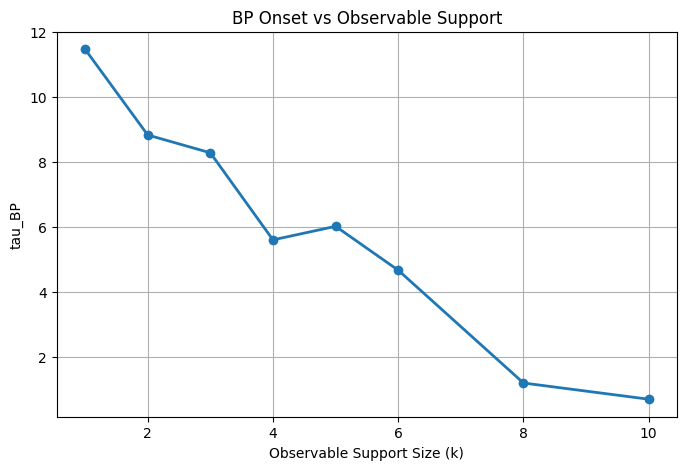

In [80]:
# ==========================================
# tau_BP vs support size
# ==========================================

ks = []
taus = []

for k in K_VALUES:

    ks.append(k)
    taus.append(
        support_results[k]["tau"]
    )

plt.figure(figsize=(8,5))

plt.plot(
    ks,
    taus,
    'o-',
    linewidth=2
)

plt.xlabel("Observable Support Size (k)")
plt.ylabel("tau_BP")
plt.title("BP Onset vs Observable Support")
plt.grid(True)

plt.show()


========== FIT ==========
b = 1.1103
correlation = -0.8456


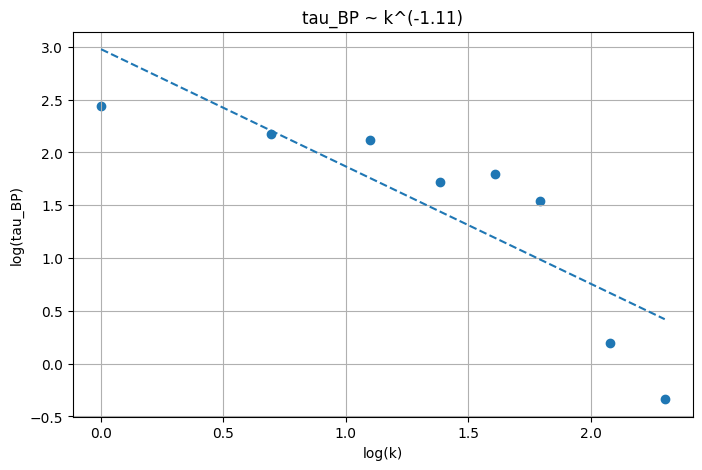

In [81]:
# ==========================================
# Fit tau_BP = A * k^(-b)
# ==========================================

log_k = np.log(ks)
log_tau = np.log(taus)

slope, intercept = np.polyfit(
    log_k,
    log_tau,
    1
)

b = -slope

r = np.corrcoef(
    log_k,
    log_tau
)[0,1]

print("\n========== FIT ==========")
print(f"b = {b:.4f}")
print(f"correlation = {r:.4f}")

plt.figure(figsize=(8,5))

plt.scatter(log_k, log_tau)

x = np.linspace(
    min(log_k),
    max(log_k),
    100
)

plt.plot(
    x,
    slope*x + intercept,
    '--'
)

plt.xlabel("log(k)")
plt.ylabel("log(tau_BP)")
plt.title(
    f"tau_BP ~ k^(-{b:.2f})"
)

plt.grid(True)

plt.show()

new k/n hypotheses

In [82]:
# ==========================================
# IMPORTS
# ==========================================

import pennylane as qml
import pennylane.numpy as np

import matplotlib.pyplot as plt

from scipy.linalg import svdvals
from scipy.optimize import curve_fit
from scipy.stats import pearsonr

In [83]:
# ==========================================
# SCALING COLLAPSE EXPERIMENT
#
# Goal:
# Test whether tau_BP depends on
#
#     k/n
#
# rather than k alone.
#
# Architectures:
# Brick-Wall only
#
# Systems:
# n = 8,10,12
#
# ==========================================

QUBIT_COUNTS = [8, 10, 12]

MAX_DEPTH = 25

N_SAMPLES = 40

In [84]:
# ==========================================
# BrickWall Ansatz
#
# Even layers:
# (0,1) (2,3) (4,5) ...
#
# Odd layers:
# (1,2) (3,4) (5,6) ...
#
# ==========================================

def BrickWall_HEA(n_qubits, params, depth):

    idx = 0

    for d in range(depth):

        # Rotation layer
        for q in range(n_qubits):

            qml.RY(
                params[idx],
                wires=q
            )

            idx += 1

        # BrickWall entanglers
        if d % 2 == 0:

            for q in range(
                0,
                n_qubits - 1,
                2
            ):
                qml.CNOT(
                    wires=[q, q + 1]
                )

        else:

            for q in range(
                1,
                n_qubits - 1,
                2
            ):
                qml.CNOT(
                    wires=[q, q + 1]
                )

In [85]:
# ==========================================
# Observable Support
#
# k=1
# Z0
#
# k=2
# Z0 Z1
#
# k=4
# Z0 Z1 Z2 Z3
#
# etc
# ==========================================

def make_observable(k):

    op = qml.PauliZ(0)

    for q in range(1, k):

        op = op @ qml.PauliZ(q)

    return op

In [86]:
# ==========================================
# Exponential Fit
#
# Var(L)=A exp(-alpha L)
#
# tau_BP = 1/alpha
#
# ==========================================

def compute_tau_bp_fit(
    variances,
    depths
):

    depths = np.array(depths)

    variances = np.array(variances)

    valid = variances > 1e-12

    depths = depths[valid]

    variances = variances[valid]

    slope, intercept = np.polyfit(
        depths,
        np.log(variances),
        1
    )

    alpha = -slope

    tau = 1 / alpha

    return tau, alpha

In [ ]:
# ==========================================
# MAIN EXPERIMENT
#
# Measure tau_BP
# for different:
#
# n
# k
#
# ==========================================

scaling_results = {}

for n in QUBIT_COUNTS:

    print("\n")
    print("="*60)
    print(f"n = {n}")
    print("="*60)

    dev = qml.device(
        "default.qubit",
        wires=n
    )

    # support sizes
    k_values = sorted(
        list(
            set(
                [
                    1,
                    2,
                    max(1, n//3),
                    n//2,
                    int(0.8*n),
                    n
                ]
            )
        )
    )

    results_for_n = {}

    for k in k_values:

        print(
            f"\nRunning n={n}, k={k}"
        )

        @qml.qnode(dev)
        def cost_circuit(
            params,
            depth
        ):

            BrickWall_HEA(
                n,
                params,
                depth
            )

            return qml.expval(
                make_observable(k)
            )

        variances = []

        for depth in range(
            1,
            MAX_DEPTH + 1
        ):

            grads_all = []

            for _ in range(
                N_SAMPLES
            ):

                params = np.random.uniform(
                    0,
                    2*np.pi,
                    size=depth*n,
                    requires_grad=True
                )

                grads = qml.grad(
                    cost_circuit
                )(
                    params,
                    depth
                )

                grads_all.extend(
                    grads
                )

            variances.append(
                np.var(grads_all)
            )

        tau, alpha = compute_tau_bp_fit(
            variances,
            range(
                1,
                MAX_DEPTH+1
            )
        )

        print(
            f"tau={tau:.3f}   alpha={alpha:.3f}"
        )

        results_for_n[k] n = {
            "tau": tau,
            "alpha": alpha
        }

    scaling_results[n] = results_for_n



n = 8

Running n=8, k=1
tau=12.269   alpha=0.082

Running n=8, k=2
tau=11.105   alpha=0.090

Running n=8, k=4
tau=11.574   alpha=0.086

Running n=8, k=6
tau=14.549   alpha=0.069

Running n=8, k=8
tau=24.038   alpha=0.042


n = 10

Running n=10, k=1
tau=11.027   alpha=0.091

Running n=10, k=2
tau=10.325   alpha=0.097

Running n=10, k=3
tau=9.812   alpha=0.102

Running n=10, k=5
tau=9.767   alpha=0.102

Running n=10, k=8
tau=12.196   alpha=0.082

Running n=10, k=10
tau=17.623   alpha=0.057


n = 12

Running n=12, k=1
tau=11.332   alpha=0.088

Running n=12, k=2
tau=10.512   alpha=0.095

Running n=12, k=4
tau=9.273   alpha=0.108

Running n=12, k=6


In [ ]:
# ==========================================
# RESULTS TABLE
# ==========================================

print("\n")

for n in scaling_results:

    print("\n")
    print(f"n = {n}")

    for k in scaling_results[n]:

        tau = scaling_results[n][k]["tau"]

        print(
            f"k={k:2d} "
            f"k/n={k/n:.3f} "
            f"tau={tau:.3f}"
        )

In [ ]:
# ==========================================
# SCALING COLLAPSE
#
# tau_BP
# versus
#
# k/n
#
# ==========================================

plt.figure(
    figsize=(9,6)
)

for n in scaling_results:

    xs = []
    ys = []

    for k in scaling_results[n]:

        xs.append(
            k / n
        )

        ys.append(
            scaling_results[n][k]["tau"]
        )

    plt.plot(
        xs,
        ys,
        marker="o",
        linewidth=2,
        label=f"n={n}"
    )

plt.xlabel(
    "Observable Fraction (k/n)"
)

plt.ylabel(
    "tau_BP"
)

plt.title(
    "Scaling Collapse Test"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
.